In [50]:
import pandas as pd
import scipy.stats as stats
import ast

url = "https://raw.githubusercontent.com/nkmwicz/worldcup2018data/refs/heads/main/cleaned_events_world_cup2018.csv"
df = pd.read_csv(url)

df.head(2)


,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0
1,8,High pass,['Accurate'],Abdullah Ibrahim Otayf,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,4.487814,High pass,258612106,35,53,75.0,19.0


In [51]:
goals=df.loc[df["tags"].apply(lambda x:"Goal" in x)]

In [52]:
for row in goals.itertuples():
    if "Goal" in row.tags or "Goal" in row.tags:
        print(row.tags)

['Goal', 'Head/body', 'Opportunity', 'Position: Goal low left', 'Accurate']
['Goal', 'Position: Goal low left', 'Not accurate']
['Goal', 'Left foot', 'Opportunity', 'Position: Goal high left', 'Accurate']
['Goal', 'Position: Goal high left', 'Not accurate']
['Head/body', 'Opportunity', 'Position: Goal high center', 'Accurate']
['Position: Goal high center', 'Accurate']
['Right foot', 'Opportunity', 'Position: Goal low center', 'Accurate']
['Position: Goal low center', 'Accurate']
['Goal', 'Head/body', 'Opportunity', 'Position: Goal low right', 'Accurate']
['Goal', 'Position: Goal low right', 'Not accurate']
['Goal', 'Left foot', 'Opportunity', 'Position: Goal high right', 'Accurate']
['Goal', 'Position: Goal high right', 'Not accurate']
['Goal', 'Right foot', 'Direct', 'Opportunity', 'Position: Goal center right', 'Accurate']
['Goal', 'Position: Goal center right', 'Not accurate']
['Right foot', 'Opportunity', 'Position: Goal low left', 'Accurate']
['Position: Goal low left', 'Accurate

In [53]:
df["tags"]=df["tags"].apply(ast.literal_eval)

In [54]:
# .apply() does not take an instantiasted function (fn())
def new_fn(fn):
    return fn(2)

def my_fn(num):
    return num**2

new_fn(my_fn)

4

In [55]:
uniquetags = set()
for taglist in df["tags"]:
    for tag in taglist:
        uniquetags.add(tag)
print(uniquetags)
uniquetags = set([tag for taglist in df["tags"] for tag in taglist])
print (uniquetags)
uniquetags


{'Position: Goal high left', 'Anticipation', 'Neutral', 'Right foot', 'Counter attack', 'Accurate', 'Left foot', 'Position: Goal center', 'Position: Out center right', 'Position: Goal center right', 'Position: Goal low left', 'Direct', 'Not accurate', 'Missed ball', 'Goal', 'Feint', 'Position: Out low right', 'Position: Post high center', 'Position: Out high center', 'Fairplay', 'Position: Out high right', 'Free space right', 'Position: Goal low center', 'Position: Post high left', 'Opportunity', 'Dangerous ball lost', 'Position: Out high left', 'High', 'Position: Post center left', 'Position: Goal low right', 'Anticipated', 'Position: Goal high right', 'Blocked', 'Position: Post low left', 'Position: Post center right', 'Key pass', 'Position: Post low right', 'Take on left', 'Yellow card', 'Position: Goal center left', 'Indirect', 'Assist', 'Position: Out center left', 'Own goal', 'Lost', 'Red card', 'Sliding tackle', 'Second yellow card', 'Head/body', 'Position: Goal high center', 'T

{'Accurate',
 'Anticipated',
 'Anticipation',
 'Assist',
 'Blocked',
 'Counter attack',
 'Dangerous ball lost',
 'Direct',
 'Fairplay',
 'Feint',
 'Free space left',
 'Free space right',
 'Goal',
 'Head/body',
 'High',
 'Indirect',
 'Interception',
 'Key pass',
 'Left foot',
 'Lost',
 'Missed ball',
 'Neutral',
 'Not accurate',
 'Opportunity',
 'Own goal',
 'Position: Goal center',
 'Position: Goal center left',
 'Position: Goal center right',
 'Position: Goal high center',
 'Position: Goal high left',
 'Position: Goal high right',
 'Position: Goal low center',
 'Position: Goal low left',
 'Position: Goal low right',
 'Position: Out center left',
 'Position: Out center right',
 'Position: Out high center',
 'Position: Out high left',
 'Position: Out high right',
 'Position: Out low left',
 'Position: Out low right',
 'Position: Post center left',
 'Position: Post center right',
 'Position: Post high center',
 'Position: Post high left',
 'Position: Post high right',
 'Position: Post lo

In [56]:
df["pass"]=(df["eventName"]=="Pass").astype(int)
df["shot"]=(df["eventName"]=="Shot").astype(int)
df["goal"]=((df["eventName"]=="Shot") & ("Goal" in df["tags"].apply(lambda x: "Goal" in x))).astype(int)
df["acc_pass"]=((df["eventName"]=="Pass") & ("Goal" in df["tags"].apply(lambda x: "Accurate" in x))).astype(int)
df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,pass,shot,goal,acc_pass
0,8,Simple pass,[Accurate],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0,1,0,0,0


In [57]:
from math import dist

def get_golden_shot(row:pd.Series):
    is_shot=row["eventName"]=="Shot"
    x_len =120
    y_len = 75
    x1 = (row["x1"]/100)*x_len
    y1 = (row["y1"]/100)*y_len
    x2 = x_len
    y2 = ((100/2)/100)*y_len
    d=dist([x1,y1],[x2,y2])
    if is_shot and d <= 18:
        return 1
    else:
        return 0

df['golden_shot']= df.apply(get_golden_shot, axis=1)
df.head(1)


,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,pass,shot,goal,acc_pass,golden_shot
0,8,Simple pass,[Accurate],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0,1,0,0,0,0


In [58]:
grp = df.groupby(["matchId","teamId"]).agg(
    shots= ("shot","sum"),
    passes= ("pass","sum"),
    goals= ("goal", "sum"),
    golden_shots = ("golden_shot","sum"),
    acc_passes=("acc_pass", "sum")
).reset_index()
grp["perc_acc_pass"]=grp["acc_passes"]/grp["passes"]
grp["perc_gold_shot"]= grp["golden_shots"]/grp["shots"]
grp

,matchId,teamId,shots,passes,goals,golden_shots,acc_passes,perc_acc_pass,perc_gold_shot
0,"Argentina - Croatia, 0 - 3",Argentina,10,476,0,7,0,0.0,0.700000
1,"Argentina - Croatia, 0 - 3",Croatia,13,334,0,5,0,0.0,0.384615
2,"Argentina - Iceland, 1 - 1",Argentina,22,744,0,6,0,0.0,0.272727
3,"Argentina - Iceland, 1 - 1",Iceland,8,183,0,3,0,0.0,0.375000
4,"Australia - Peru, 0 - 2",Australia,11,512,0,7,0,0.0,0.636364
...,...,...,...,...,...,...,...,...,...
123,"Uruguay - Portugal, 2 - 1",Uruguay,6,238,0,1,0,0.0,0.166667
124,"Uruguay - Russia, 3 - 0",Russia,3,327,0,0,0,0.0,0.000000
125,"Uruguay - Russia, 3 - 0",Uruguay,12,466,0,5,0,0.0,0.416667
126,"Uruguay - Saudi Arabia, 1 - 0",Saudi Arabia,7,553,0,2,0,0.0,0.285714


In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

def viz_corr(x:str,y:str):
    plt.figure(figsize=(5,3))
    r,p = stats.pearsonr(grp[x],grp[y])
    r2=r**2
    reg=sns.regplot(data=grp,x=x,y=y, line_kws={"color":"red"})
    text=f"""r={r:4f}
    p={p:.4f}
    r2={r2:.4f}"""
    reg.text(
        0.1,
        0.7,
        text,
        transform=reg.transAxes,
        bbox={"boxstyle":"round,pad=0.5","fc": "white"}
    )
    plt.show()
    

/var/folders/m9/z30nfghs5xs3cndqgmk7rr200000gn/T/ipykernel_20249/2290974507.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,p = stats.pearsonr(grp[x],grp[y])


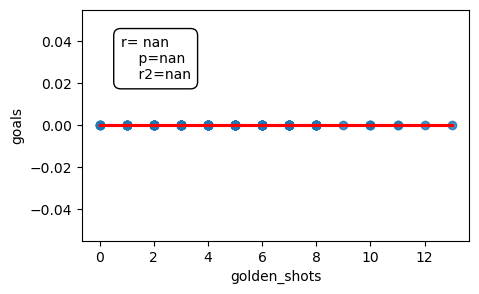

In [61]:
viz_corr("golden_shots", "goals")